# Phase 4: Feature Engineering

## Step 1 — Feature Availability & Target Leakage Assessment
### Introduction / Objective

EDA identified several features that may contain information generated after the point where `final_pass` is predicted.

Potential leakage candidates are:

- `decision_rework`
- `defect_type`
- `rework_time_min`
- `defect_severity_0to3`
- `scrap`
- `warranty_claim_90d`

The objective of this section is to inspect these features and determine whether they are available before the prediction point.

Features that are generated after the prediction point will be excluded from the ML feature set to prevent target leakage.

In [162]:
# Load required libraries
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv(
    "../data/raw/manufacturing_quality_decisions_10000.csv"
)

# Display dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (10000, 23)

Columns:
['event_id', 'event_ts', 'plant', 'line', 'shift', 'machine_id', 'operator_id', 'machine_age_yrs', 'material_grade', 'temp_c', 'humidity_pct', 'process_speed_units_hr', 'inspection_method', 'defect_type', 'defect_severity_0to3', 'decision_rework', 'rework_time_min', 'final_pass', 'scrap', 'total_cycle_time_min', 'energy_kwh', 'cost_usd', 'warranty_claim_90d']


In [163]:
# Define potential leakage features
leakage_candidates = [
    "decision_rework",
    "rework_time_min",
    "defect_type",
    "defect_severity_0to3",
    "scrap",
    "warranty_claim_90d"
]

# Check whether all candidate features exist
missing_candidates = [
    col for col in leakage_candidates
    if col not in df.columns
]

print("Missing leakage candidate columns:", missing_candidates)

Missing leakage candidate columns: []


In [164]:
# Inspect data types and missing values
leakage_info = pd.DataFrame({
    "Data Type": df[leakage_candidates].dtypes,
    "Missing Values": df[leakage_candidates].isnull().sum(),
    "Unique Values": df[leakage_candidates].nunique()
})

leakage_info

,Data Type,Missing Values,Unique Values
decision_rework,int64,0,2
rework_time_min,float64,0,513
defect_type,object,0,6
defect_severity_0to3,int64,0,4
scrap,int64,0,2
warranty_claim_90d,int64,0,2


In [165]:
# Display sample values
for col in leakage_candidates:
    print(f"\n{'=' * 60}")
    print(f"Feature: {col}")
    print(df[col].head(10).to_list())


Feature: decision_rework
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]

Feature: rework_time_min
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Feature: defect_type
['none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none']

Feature: defect_severity_0to3
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Feature: scrap
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Feature: warranty_claim_90d
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [166]:
# Examine value distributions
for col in leakage_candidates:
    print(f"\n{'=' * 60}")
    print(f"Value Distribution: {col}")
    print(df[col].value_counts(dropna=False))


Value Distribution: decision_rework
decision_rework
0    7566
1    2434
Name: count, dtype: int64

Value Distribution: rework_time_min
rework_time_min
0.0     7665
10.5      16
5.3       13
11.2      13
7.9       13
        ... 
25.7       1
60.0       1
39.1       1
40.5       1
1.1        1
Name: count, Length: 513, dtype: int64

Value Distribution: defect_type
defect_type
none             8403
dimension         332
finish            324
contamination     320
crack             311
scratch           310
Name: count, dtype: int64

Value Distribution: defect_severity_0to3
defect_severity_0to3
0    8403
2     691
1     603
3     303
Name: count, dtype: int64

Value Distribution: scrap
scrap
0    9752
1     248
Name: count, dtype: int64

Value Distribution: warranty_claim_90d
warranty_claim_90d
0    9875
1     125
Name: count, dtype: int64


In [167]:
# Compare leakage candidates with the target
for col in leakage_candidates:
    print(f"\n{'=' * 60}")
    print(f"Feature vs final_pass: {col}")
    
    print(
        pd.crosstab(
            df[col],
            df["final_pass"],
            normalize="index"
        )
    )


Feature vs final_pass: decision_rework
final_pass              0         1
decision_rework                    
0                0.110759  0.889241
1                0.164749  0.835251

Feature vs final_pass: rework_time_min
final_pass             0        1
rework_time_min                  
0.0              0.10972  0.89028
0.1              0.00000  1.00000
0.2              0.00000  1.00000
0.3              0.00000  1.00000
0.4              0.20000  0.80000
...                  ...      ...
54.6             0.50000  0.50000
55.5             0.00000  1.00000
57.8             1.00000  0.00000
58.2             1.00000  0.00000
60.0             1.00000  0.00000

[513 rows x 2 columns]

Feature vs final_pass: defect_type
final_pass            0         1
defect_type                      
contamination  0.306250  0.693750
crack          0.337621  0.662379
dimension      0.271084  0.728916
finish         0.330247  0.669753
none           0.087826  0.912174
scratch        0.325806  0.674194

F

In [168]:
# Correlation with the target for numerical/binary leakage candidates
numeric_candidates = df[leakage_candidates].select_dtypes(
    include=np.number
).columns

leakage_target_correlation = (
    df[list(numeric_candidates) + ["final_pass"]]
    .corr()["final_pass"]
    .drop("final_pass")
    .sort_values(ascending=False)
)

leakage_target_correlation

decision_rework        -0.070323
warranty_claim_90d     -0.113408
rework_time_min        -0.185872
defect_severity_0to3   -0.294066
scrap                  -0.424053
Name: final_pass, dtype: float64

## Observations / Insights

- The identified leakage candidates were inspected for data type, missing values, cardinality, and value distribution.
- `rework_time_min`, `scrap`, and `warranty_claim_90d` represent information that is likely generated after the prediction point and therefore have high leakage risk.
- `decision_rework` and `defect_severity_0to3` require confirmation of when they are recorded before making the final decision.
- Correlation with `final_pass` is used only as supporting evidence; leakage is primarily determined by feature availability at prediction time.
- Features confirmed to be generated after the prediction point will be excluded from the final ML feature set.

## Step 2 — Identifier Feature Assessment
### Introduction / Objective

EDA identified three identifier-related features:

- `event_id`
- `machine_id`
- `operator_id`

These features need to be evaluated before modeling because identifiers may not contain meaningful predictive information and high-cardinality identifiers can cause unnecessary model complexity.

The objective is to examine their uniqueness, cardinality, and relationship with `final_pass` and decide whether each feature should be kept, transformed, or removed.

In [169]:
# Identifier features
identifier_features = [
    "event_id",
    "machine_id",
    "operator_id"
]

# Check basic information
identifier_info = pd.DataFrame({
    "Data Type": df[identifier_features].dtypes,
    "Unique Values": df[identifier_features].nunique(),
    "Unique Ratio": [
        df[col].nunique() / len(df)
        for col in identifier_features
    ],
    "Missing Values": df[identifier_features].isnull().sum()
})

identifier_info

,Data Type,Unique Values,Unique Ratio,Missing Values
event_id,object,10000,1.000,0
machine_id,object,60,0.006,0
operator_id,object,450,0.045,0


In [170]:
# Display sample values
for col in identifier_features:
    print(f"\n{'=' * 50}")
    print(f"{col}")
    print(df[col].head(10).to_list())


event_id
['M200000', 'M200001', 'M200002', 'M200003', 'M200004', 'M200005', 'M200006', 'M200007', 'M200008', 'M200009']

machine_id
['MC104', 'MC158', 'MC144', 'MC108', 'MC113', 'MC103', 'MC116', 'MC141', 'MC114', 'MC118']

operator_id
['OP1009', 'OP1419', 'OP1042', 'OP1013', 'OP1312', 'OP1108', 'OP1124', 'OP1061', 'OP1134', 'OP1234']


In [171]:
# Check relationship between identifiers and target
for col in identifier_features:
    print(f"\n{'=' * 60}")
    print(f"Target distribution by {col}")
    
    print(
        pd.crosstab(
            df[col],
            df["final_pass"],
            normalize="index"
        ).head(20)
    )


Target distribution by event_id
final_pass    0    1
event_id            
M200000     0.0  1.0
M200001     0.0  1.0
M200002     0.0  1.0
M200003     0.0  1.0
M200004     0.0  1.0
M200005     0.0  1.0
M200006     0.0  1.0
M200007     0.0  1.0
M200008     0.0  1.0
M200009     0.0  1.0
M200010     1.0  0.0
M200011     1.0  0.0
M200012     0.0  1.0
M200013     0.0  1.0
M200014     0.0  1.0
M200015     0.0  1.0
M200016     0.0  1.0
M200017     0.0  1.0
M200018     0.0  1.0
M200019     1.0  0.0

Target distribution by machine_id
final_pass         0         1
machine_id                    
MC100       0.106509  0.893491
MC101       0.159091  0.840909
MC102       0.168605  0.831395
MC103       0.090361  0.909639
MC104       0.128655  0.871345
MC105       0.128205  0.871795
MC106       0.065089  0.934911
MC107       0.127660  0.872340
MC108       0.151899  0.848101
MC109       0.090909  0.909091
MC110       0.121212  0.878788
MC111       0.145695  0.854305
MC112       0.145251  0.854749
MC113

In [172]:
# Check number of records per machine and operator
print("Records per machine:")
print(df["machine_id"].value_counts().describe())

print("\nRecords per operator:")
print(df["operator_id"].value_counts().describe())

Records per machine:
count     60.000000
mean     166.666667
std       11.914479
min      143.000000
25%      156.000000
50%      166.000000
75%      176.000000
max      196.000000
Name: count, dtype: float64

Records per operator:
count    450.000000
mean      22.222222
std        4.641197
min       10.000000
25%       19.000000
50%       22.000000
75%       25.000000
max       36.000000
Name: count, dtype: float64


## Observations / Insights

- `event_id` has 10,000 unique values for 10,000 records and is therefore treated as a record identifier and removed.
- `operator_id` has 450 unique values with relatively few observations per operator and is excluded to avoid unnecessary high-cardinality encoding and potential memorization.
- `machine_id` has 60 unique machines with sufficient repeated observations and will be retained initially as a potentially meaningful manufacturing feature.
- `machine_id` will be evaluated further during model development to determine whether it improves prediction.

## Step 3 — Define Final Features (X) and Target (y)
### Introduction / Objective

After the leakage and identifier assessment, we need to separate the target variable from the predictor features.

The objective is to create:

- `X` → features used by the model for prediction
- `y` → target variable `final_pass`

This ensures that the target and any confirmed invalid/leakage features are not accidentally included in the model inputs.

In [173]:
# Target variable
target_column = "final_pass"

# Features confirmed to be removed due to leakage
leakage_features_to_remove = [
    "rework_time_min",
    "scrap",
    "warranty_claim_90d"
]

# Features currently excluded as identifiers
identifier_features_to_remove = [
    "event_id",
    "operator_id"
]
# Combine columns to remove
columns_to_remove = (
    [target_column]
    + leakage_features_to_remove
    + identifier_features_to_remove
)

# Create X and y
X = df.drop(columns=columns_to_remove)
y = df[target_column]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (10000, 17)
Target Shape: (10000,)


In [174]:
# Display final candidate features
print("Candidate Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Candidate Features:
['event_ts', 'plant', 'line', 'shift', 'machine_id', 'machine_age_yrs', 'material_grade', 'temp_c', 'humidity_pct', 'process_speed_units_hr', 'inspection_method', 'defect_type', 'defect_severity_0to3', 'decision_rework', 'total_cycle_time_min', 'energy_kwh', 'cost_usd']

Target:
final_pass


In [175]:
# Verify that target is not present in X
print("Target present in X:", target_column in X.columns)

# Verify removed leakage features are not present
remaining_leakage = [
    col for col in leakage_features_to_remove
    if col in X.columns
]

print("Remaining leakage features:", remaining_leakage)

Target present in X: False
Remaining leakage features: []


In [176]:
# Display target distribution
target_distribution = (
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Percentage")
)

target_distribution

final_pass
1    87.61
0    12.39
Name: Percentage, dtype: float64

## Observations / Insights

- `final_pass` is separated as the target variable `y`.
- Confirmed leakage features are excluded from the candidate feature matrix.
- `event_id` is excluded because it is a record identifier.
- `operator_id` is excluded because of its relatively high cardinality and limited observations per operator.
- `machine_id` is retained initially because it represents a recurring manufacturing entity with sufficient observations.
- The resulting `X` contains the current candidate predictor features for preprocessing.
- The target distribution confirms the previously identified class imbalance.

## Step 4 — Train-Test Split
### Introduction / Objective

Before applying preprocessing techniques that learn from the data, we need to divide the dataset into training and testing sets.

The objective is to:

- Use the training set to learn preprocessing parameters and train models.
- Keep the test set completely unseen during training.
- Maintain the original `final_pass` class distribution using stratified splitting.

An 80:20 train-test split will be used.

In [177]:
from sklearn.model_selection import train_test_split

# Stratified 80:20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("\nTraining Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (8000, 17)
Testing Features Shape: (2000, 17)

Training Target Shape: (8000,)
Testing Target Shape: (2000,)


In [178]:
# Compare target distribution before and after splitting

distribution_check = pd.DataFrame({
    "Full Dataset (%)": y.value_counts(normalize=True).mul(100),
    "Training (%)": y_train.value_counts(normalize=True).mul(100),
    "Testing (%)": y_test.value_counts(normalize=True).mul(100)
}).round(2)

distribution_check

,Full Dataset (%),Training (%),Testing (%)
final_pass,,,
1,87.61,87.61,87.6
0,12.39,12.39,12.4


In [179]:
# Verify that there is no overlap between training and testing indices
overlap = set(X_train.index).intersection(set(X_test.index))

print("Overlapping records:", len(overlap))

Overlapping records: 0


## Observations / Insights

- The dataset was split into 80% training and 20% testing data.
- Stratification was used to maintain a similar `final_pass` class distribution in both sets.
- `random_state=42` ensures reproducibility.
- No records should overlap between the training and testing sets.
- All preprocessing steps that learn parameters will be fitted using the training data only.
- The test set will remain unseen until model evaluation.

## Step 5 — Missing Value Assessment & Handling
### Introduction / Objective

Before applying encoding, scaling, and other transformations, we need to check the training and testing datasets for missing values.

The objective is to:

- Identify missing values in the current feature set.
- Determine whether imputation is actually required.
- Avoid unnecessary data transformation.
- Ensure the final ML pipeline contains no unexpected missing values.

Missing-value handling will be fitted on the training data only.

In [180]:
# Check missing values in training data
train_missing = (
    X_train.isnull()
    .sum()
    .sort_values(ascending=False)
)

train_missing[train_missing > 0]

Series([], dtype: int64)

In [181]:
# Check missing values in testing data
test_missing = (
    X_test.isnull()
    .sum()
    .sort_values(ascending=False)
)

test_missing[test_missing > 0]

Series([], dtype: int64)

In [182]:
# Create a complete missing-value summary
missing_summary = pd.DataFrame({
    "Training Missing": X_train.isnull().sum(),
    "Testing Missing": X_test.isnull().sum(),
    "Training Missing %": (
        X_train.isnull().mean() * 100
    ).round(2),
    "Testing Missing %": (
        X_test.isnull().mean() * 100
    ).round(2)
})

missing_summary = missing_summary[
    (missing_summary["Training Missing"] > 0) |
    (missing_summary["Testing Missing"] > 0)
]

missing_summary

,Training Missing,Testing Missing,Training Missing %,Testing Missing %


In [183]:
# Check for infinite values
numeric_train = X_train.select_dtypes(include=np.number)

infinite_values = np.isinf(numeric_train).sum()

print("Infinite values in training data:")
print(infinite_values[infinite_values > 0])

Infinite values in training data:
Series([], dtype: int64)


## Observations / Insights

- The training and testing datasets were checked independently for missing values.
- No imputation will be performed if the final feature set contains no missing values.
- If missing values are present, numerical features will use appropriate numerical imputation and categorical features will use appropriate categorical imputation.
- Any imputation required during preprocessing will be fitted only on the training data to prevent data leakage.
- Infinite numerical values will also be checked before continuing to the next preprocessing step.

## Step 6 — Categorical Feature Encoding
### Introduction / Objective

The dataset contains categorical features that machine learning models cannot directly process as numerical inputs.

The objective is to convert categorical features into ML-compatible numerical representations while keeping the transformation simple and interpretable.

One-Hot Encoding will be used for categorical features with manageable cardinality.

In [184]:
# Identify categorical and numerical features

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

# Raw timestamp should not be treated as a categorical feature
if "event_ts" in categorical_features:
    categorical_features.remove("event_ts")

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['plant', 'line', 'shift', 'machine_id', 'material_grade', 'inspection_method', 'defect_type']

Numerical Features:
['machine_age_yrs', 'temp_c', 'humidity_pct', 'process_speed_units_hr', 'defect_severity_0to3', 'decision_rework', 'total_cycle_time_min', 'energy_kwh', 'cost_usd']


In [185]:
# Check cardinality of categorical features

categorical_cardinality = pd.DataFrame({
    "Unique Values": X_train[categorical_features].nunique(),
    "Missing Values": X_train[categorical_features].isnull().sum()
}).sort_values(
    "Unique Values",
    ascending=False
)

categorical_cardinality

,Unique Values,Missing Values
machine_id,60,0
defect_type,6,0
line,4,0
shift,3,0
plant,3,0
material_grade,3,0
inspection_method,3,0


In [186]:
from sklearn.preprocessing import OneHotEncoder

# Create One-Hot Encoder
one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit only on training categorical features
X_train_encoded = one_hot_encoder.fit_transform(
    X_train[categorical_features]
)

# Transform testing categorical features
X_test_encoded = one_hot_encoder.transform(
    X_test[categorical_features]
)

print("Encoded Training Shape:", X_train_encoded.shape)
print("Encoded Testing Shape:", X_test_encoded.shape)

Encoded Training Shape: (8000, 82)
Encoded Testing Shape: (2000, 82)


In [187]:
# Get generated feature names

encoded_feature_names = (
    one_hot_encoder
    .get_feature_names_out(categorical_features)
)

print("Number of encoded features:", len(encoded_feature_names))
print("\nEncoded Features:")
print(encoded_feature_names)

Number of encoded features: 82

Encoded Features:
['plant_plant_1' 'plant_plant_2' 'plant_plant_3' 'line_line_A'
 'line_line_B' 'line_line_C' 'line_line_D' 'shift_day' 'shift_night'
 'shift_swing' 'machine_id_MC100' 'machine_id_MC101' 'machine_id_MC102'
 'machine_id_MC103' 'machine_id_MC104' 'machine_id_MC105'
 'machine_id_MC106' 'machine_id_MC107' 'machine_id_MC108'
 'machine_id_MC109' 'machine_id_MC110' 'machine_id_MC111'
 'machine_id_MC112' 'machine_id_MC113' 'machine_id_MC114'
 'machine_id_MC115' 'machine_id_MC116' 'machine_id_MC117'
 'machine_id_MC118' 'machine_id_MC119' 'machine_id_MC120'
 'machine_id_MC121' 'machine_id_MC122' 'machine_id_MC123'
 'machine_id_MC124' 'machine_id_MC125' 'machine_id_MC126'
 'machine_id_MC127' 'machine_id_MC128' 'machine_id_MC129'
 'machine_id_MC130' 'machine_id_MC131' 'machine_id_MC132'
 'machine_id_MC133' 'machine_id_MC134' 'machine_id_MC135'
 'machine_id_MC136' 'machine_id_MC137' 'machine_id_MC138'
 'machine_id_MC139' 'machine_id_MC140' 'machine_id

## Observations / Insights

- Categorical features were identified separately from numerical features.
- One-Hot Encoding was selected because the categorical variables have manageable cardinality and the method is simple and interpretable.
- `handle_unknown="ignore"` ensures that unseen categories in the test or future prediction data do not cause errors.
- The encoder was fitted only on the training data.
- The number of features increased after encoding because each category is represented as a separate binary feature.
- The encoded feature set will be integrated with the numerical preprocessing pipeline in a later section.

## Step 7 — Numerical Feature Assessment & Scaling
### Introduction / Objective

Numerical features have different scales and distributions. Before modeling, they need to be assessed for scale differences and suitability for transformation.

The objective is to:

- Identify the numerical features.
- Compare their scales.
- Determine whether scaling is required.
- Prepare the numerical preprocessing strategy.

Scaling will mainly be required for scale-sensitive models. Tree-based models generally do not require feature scaling.

In [188]:
# Display numerical feature summary

numerical_summary = X_train[numerical_features].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
machine_age_yrs,8000.0,6.032400,2.941706,0.200,3.990,6.050,8.040,16.960
temp_c,8000.0,12.624400,4.372067,5.000,9.300,12.200,15.800,28.100
humidity_pct,8000.0,52.160275,12.618175,18.200,41.900,52.800,62.300,86.700
process_speed_units_hr,8000.0,121.770587,25.047862,60.000,104.800,121.400,138.900,190.000
defect_severity_0to3,8000.0,0.291750,0.728662,0.000,0.000,0.000,0.000,3.000
decision_rework,8000.0,0.245375,0.430336,0.000,0.000,0.000,0.000,1.000
total_cycle_time_min,8000.0,34.560212,12.143798,12.400,27.300,31.300,36.700,97.600
energy_kwh,8000.0,1.422082,0.214270,0.902,1.284,1.386,1.508,2.486
cost_usd,8000.0,29.036082,17.091177,10.510,21.620,24.870,29.180,164.310


In [189]:
# Check scale differences

scale_summary = pd.DataFrame({
    "Minimum": X_train[numerical_features].min(),
    "Maximum": X_train[numerical_features].max(),
    "Mean": X_train[numerical_features].mean(),
    "Std": X_train[numerical_features].std()
}).round(3)

scale_summary

,Minimum,Maximum,Mean,Std
machine_age_yrs,0.200,16.960,6.032,2.942
temp_c,5.000,28.100,12.624,4.372
humidity_pct,18.200,86.700,52.160,12.618
process_speed_units_hr,60.000,190.000,121.771,25.048
defect_severity_0to3,0.000,3.000,0.292,0.729
decision_rework,0.000,1.000,0.245,0.430
total_cycle_time_min,12.400,97.600,34.560,12.144
energy_kwh,0.902,2.486,1.422,0.214
cost_usd,10.510,164.310,29.036,17.091


In [190]:
# Calculate skewness of numerical features

skewness_summary = (
    X_train[numerical_features]
    .skew()
    .sort_values(ascending=False)
    .to_frame(name="Skewness")
)

skewness_summary

,Skewness
cost_usd,4.394812
defect_severity_0to3,2.492683
total_cycle_time_min,1.876453
energy_kwh,1.226872
decision_rework,1.183673
temp_c,0.360346
machine_age_yrs,0.112616
process_speed_units_hr,0.069852
humidity_pct,-0.093079


In [191]:
# Check potential outliers using IQR

outlier_summary = []

for col in numerical_features:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (X_train[col] < lower_bound) |
        (X_train[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Outliers": outliers,
        "Outlier %": round(outliers / len(X_train) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Outliers,Outlier %
0,machine_age_yrs,33,0.41
1,temp_c,7,0.09
2,humidity_pct,0,0.00
3,process_speed_units_hr,0,0.00
4,defect_severity_0to3,1289,16.11
5,decision_rework,1963,24.54
6,total_cycle_time_min,824,10.30
7,energy_kwh,484,6.05
8,cost_usd,832,10.40


## Observations / Insights

- Numerical features were reviewed for scale differences, skewness, and potential outliers.
- Features with different scales may require standardization for scale-sensitive models.
- Skewed distributions will not automatically be transformed; transformations will only be applied where they provide a clear modeling benefit.
- Potential outliers will be investigated in the next section rather than automatically removed.
- `StandardScaler` will be considered for models that are sensitive to feature scale.
- Tree-based models will generally use the numerical features without scaling.

## Step 8 — Outlier & Skewness Treatment
### Introduction / Objective

EDA identified potential outliers and skewed numerical features.

The objective is to determine whether these observations represent:

- Genuine manufacturing variation
- Extreme but valid production conditions
- Clearly incorrect data

Outliers will not be removed automatically, and transformations will only be applied when they are justified.

In [192]:
# Review skewness and outlier percentages together

outlier_skewness_summary = skewness_summary.copy()

outlier_skewness_summary["Outlier %"] = (
    outlier_summary
    .set_index("Feature")["Outlier %"]
)

outlier_skewness_summary = (
    outlier_skewness_summary
    .sort_values("Outlier %", ascending=False)
)

outlier_skewness_summary

,Skewness,Outlier %
decision_rework,1.183673,24.54
defect_severity_0to3,2.492683,16.11
cost_usd,4.394812,10.40
total_cycle_time_min,1.876453,10.30
energy_kwh,1.226872,6.05
machine_age_yrs,0.112616,0.41
temp_c,0.360346,0.09
process_speed_units_hr,0.069852,0.00
humidity_pct,-0.093079,0.00


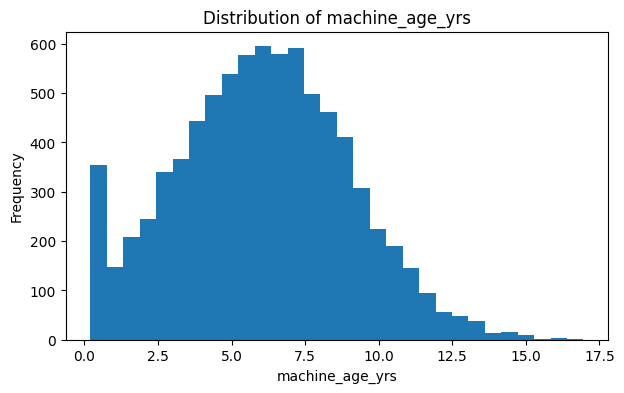

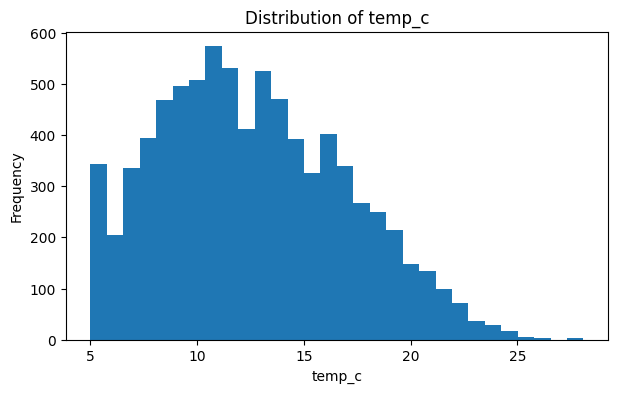

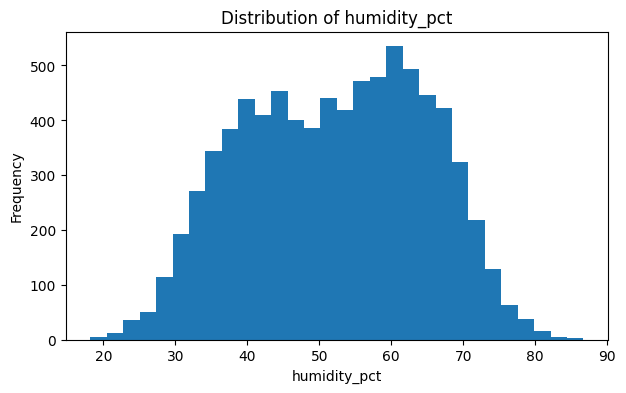

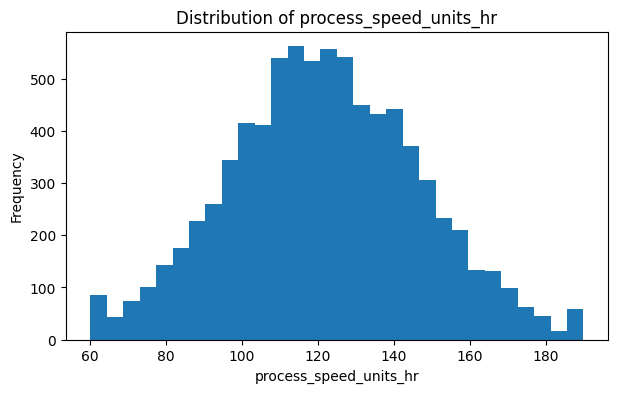

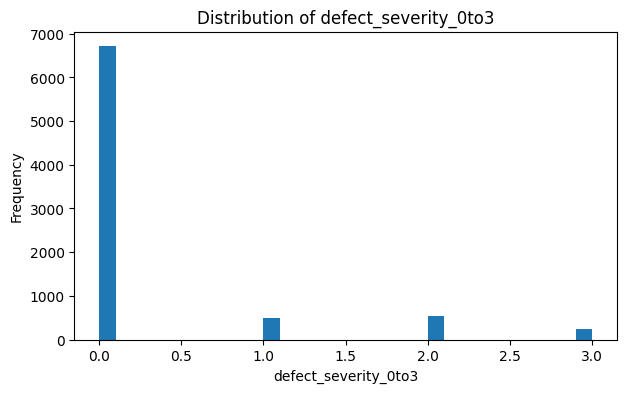

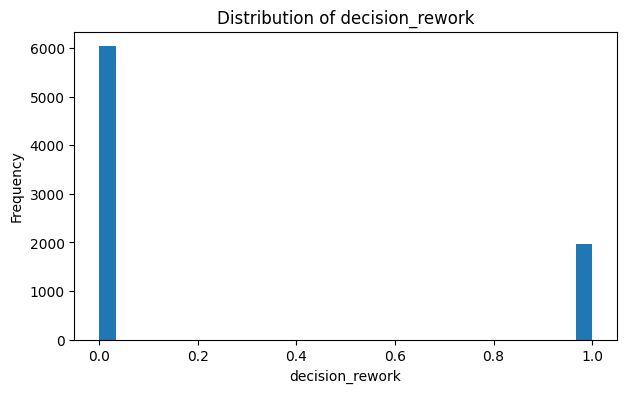

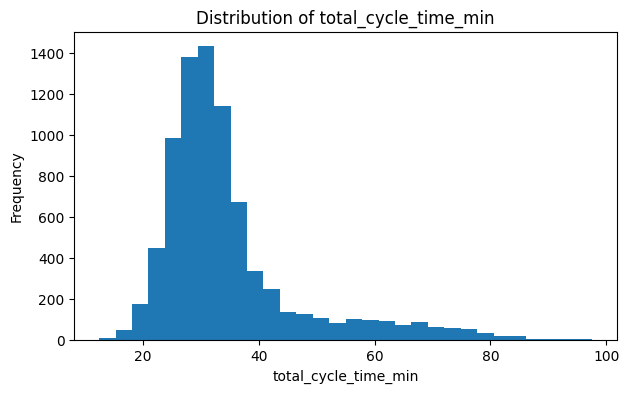

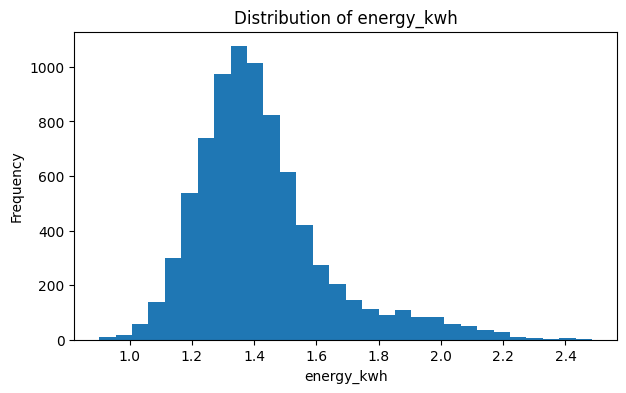

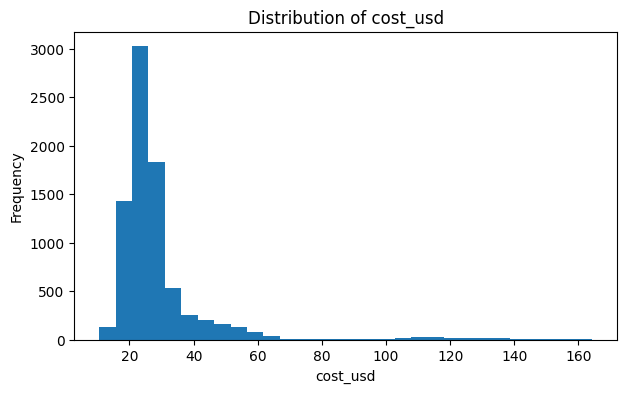

In [193]:
# Display selected numerical distributions

import matplotlib.pyplot as plt

for col in numerical_features:
    plt.figure(figsize=(7, 4))
    plt.hist(X_train[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [194]:
# Identify highly skewed continuous features

highly_skewed_features = (
    skewness_summary[
        skewness_summary["Skewness"].abs() > 1
    ]
    .index
    .tolist()
)

print("Highly skewed features:")
print(highly_skewed_features)

Highly skewed features:
['cost_usd', 'defect_severity_0to3', 'total_cycle_time_min', 'energy_kwh', 'decision_rework']


In [195]:
# Identify binary / low-cardinality numerical features

low_cardinality_numeric = {
    col: X_train[col].nunique()
    for col in numerical_features
    if X_train[col].nunique() <= 5
}

low_cardinality_numeric

{'defect_severity_0to3': 4, 'decision_rework': 2}

## Observations / Insights

- Potential outliers were identified using the IQR method.
- Skewness was reviewed alongside feature cardinality and distributions.
- Binary or low-cardinality features will not be transformed simply because they show high skewness.
- Genuine extreme manufacturing observations will generally be retained because they may contain useful defect-related information.
- Clearly erroneous values, if identified, will be corrected or removed.
- Log or other transformations will only be applied to genuinely continuous features when there is a clear modeling benefit.
- No blanket outlier removal or transformation will be performed.

## Step 9 — Feature Creation
### Introduction / Objective

EDA and domain understanding can be used to create a small number of meaningful manufacturing features.

The objective is to create features that capture useful operational patterns without generating unnecessary or highly complex combinations.

Only features that are available before the prediction point will be considered.

In [196]:
# Create a working copy of the training and testing data

X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

print("Training Shape Before Feature Creation:", X_train_fe.shape)
print("Testing Shape Before Feature Creation:", X_test_fe.shape)

Training Shape Before Feature Creation: (8000, 17)
Testing Shape Before Feature Creation: (2000, 17)


In [197]:
# Convert event timestamp into useful time-based features

if "event_ts" in X_train_fe.columns:

    X_train_fe["event_ts"] = pd.to_datetime(
        X_train_fe["event_ts"]
    )

    X_test_fe["event_ts"] = pd.to_datetime(
        X_test_fe["event_ts"]
    )

    # Extract useful temporal features
    X_train_fe["event_hour"] = X_train_fe["event_ts"].dt.hour
    X_test_fe["event_hour"] = X_test_fe["event_ts"].dt.hour

    X_train_fe["event_day_of_week"] = (
        X_train_fe["event_ts"].dt.dayofweek
    )

    X_test_fe["event_day_of_week"] = (
        X_test_fe["event_ts"].dt.dayofweek
    )

    X_train_fe["event_month"] = X_train_fe["event_ts"].dt.month
    X_test_fe["event_month"] = X_test_fe["event_ts"].dt.month

    # Remove raw timestamp
    X_train_fe.drop(
        columns=["event_ts"],
        inplace=True
    )

    X_test_fe.drop(
        columns=["event_ts"],
        inplace=True
    )

    print("Created temporal features:")
    print([
        "event_hour",
        "event_day_of_week",
        "event_month"
    ])

Created temporal features:
['event_hour', 'event_day_of_week', 'event_month']


In [198]:
# Inspect numerical feature ranges before creating new features

feature_ranges = pd.DataFrame({
    "Minimum": X_train_fe[numerical_features].min(),
    "Maximum": X_train_fe[numerical_features].max(),
    "Mean": X_train_fe[numerical_features].mean()
}).round(3)

feature_ranges

,Minimum,Maximum,Mean
machine_age_yrs,0.200,16.960,6.032
temp_c,5.000,28.100,12.624
humidity_pct,18.200,86.700,52.160
process_speed_units_hr,60.000,190.000,121.771
defect_severity_0to3,0.000,3.000,0.292
decision_rework,0.000,1.000,0.245
total_cycle_time_min,12.400,97.600,34.560
energy_kwh,0.902,2.486,1.422
cost_usd,10.510,164.310,29.036


In [199]:
# Machine age grouping
# Created only if machine_age_yrs is available in the final feature set

if "machine_age_yrs" in X_train_fe.columns:

    bins = [-np.inf, 5, 10, np.inf]
    labels = ["New", "Moderate", "Old"]

    X_train_fe["machine_age_group"] = pd.cut(
        X_train_fe["machine_age_yrs"],
        bins=bins,
        labels=labels
    )

    X_test_fe["machine_age_group"] = pd.cut(
        X_test_fe["machine_age_yrs"],
        bins=bins,
        labels=labels
    )

    print("Created feature: machine_age_group")

Created feature: machine_age_group


In [200]:
# Create operational interaction features only when
# both variables are available at prediction time

if {"plant", "shift"}.issubset(X_train_fe.columns):

    X_train_fe["plant_shift"] = (
        X_train_fe["plant"].astype(str)
        + "_" +
        X_train_fe["shift"].astype(str)
    )

    X_test_fe["plant_shift"] = (
        X_test_fe["plant"].astype(str)
        + "_" +
        X_test_fe["shift"].astype(str)
    )

    print("Created feature: plant_shift")


if {"material_grade", "shift"}.issubset(X_train_fe.columns):

    X_train_fe["material_shift"] = (
        X_train_fe["material_grade"].astype(str)
        + "_" +
        X_train_fe["shift"].astype(str)
    )

    X_test_fe["material_shift"] = (
        X_test_fe["material_grade"].astype(str)
        + "_" +
        X_test_fe["shift"].astype(str)
    )

    print("Created feature: material_shift")

Created feature: plant_shift
Created feature: material_shift


In [201]:
# Check the newly created features

new_features = [
    col for col in X_train_fe.columns
    if col not in X_train.columns
]

print("New Features:")
print(new_features)

print("\nTraining Shape After Feature Creation:", X_train_fe.shape)
print("Testing Shape After Feature Creation:", X_test_fe.shape)

New Features:
['event_hour', 'event_day_of_week', 'event_month', 'machine_age_group', 'plant_shift', 'material_shift']

Training Shape After Feature Creation: (8000, 22)
Testing Shape After Feature Creation: (2000, 22)


In [202]:
# Check missing values created by feature engineering

print("Missing values in new training features:")
print(X_train_fe[new_features].isnull().sum())

print("\nMissing values in new testing features:")
print(X_test_fe[new_features].isnull().sum())

Missing values in new training features:
event_hour           0
event_day_of_week    0
event_month          0
machine_age_group    0
plant_shift          0
material_shift       0
dtype: int64

Missing values in new testing features:
event_hour           0
event_day_of_week    0
event_month          0
machine_age_group    0
plant_shift          0
material_shift       0
dtype: int64


## Observations / Insights

- A limited number of domain-relevant features were created.
- `machine_age_group` represents the operational age category of the machine.
- `plant_shift` captures the combination of manufacturing location and shift.
- `material_shift` captures the relationship between material grade and operating shift.
- No arbitrary large-scale feature combinations were created.
- Newly created features will be evaluated during feature selection and may be removed if they do not provide useful information.
- Only prediction-time features were used for feature creation.

## Step 10 — Feature Selection & Correlation Analysis
## Introduction / Objective

EDA identified highly correlated numerical features, including:

- `rework_time_min` ↔ `total_cycle_time_min` = 0.92
- `total_cycle_time_min` ↔ `energy_kwh` = 0.90

Feature selection is required to identify redundant, irrelevant, or potentially useful features.

The objective is to combine statistical evidence, model usefulness, and business meaning when deciding which features to retain.

High correlation alone will not automatically result in feature removal.

In [203]:
# Check correlation between numerical features

correlation_matrix = X_train_fe[
    X_train_fe.select_dtypes(include=np.number).columns
].corr()

correlation_matrix.round(2)

,machine_age_yrs,temp_c,humidity_pct,process_speed_units_hr,defect_severity_0to3,decision_rework,total_cycle_time_min,energy_kwh,cost_usd,event_hour,event_day_of_week,event_month
machine_age_yrs,1.00,0.01,-0.01,0.01,0.08,0.05,0.07,0.06,0.08,0.01,0.00,-0.01
temp_c,0.01,1.00,0.11,0.01,0.01,0.00,0.01,0.00,-0.00,0.01,-0.01,-0.35
humidity_pct,-0.01,0.11,1.00,0.02,0.03,0.03,0.03,0.03,0.02,0.01,-0.00,0.26
process_speed_units_hr,0.01,0.01,0.02,1.00,0.08,0.03,0.23,0.43,0.15,-0.03,-0.01,0.00
defect_severity_0to3,0.08,0.01,0.03,0.08,1.00,0.54,0.78,0.68,0.73,-0.01,-0.01,0.01
decision_rework,0.05,0.00,0.03,0.03,0.54,1.00,0.71,0.61,0.51,0.00,-0.00,-0.01
total_cycle_time_min,0.07,0.01,0.03,0.23,0.78,0.71,1.00,0.90,0.74,-0.00,-0.01,-0.00
energy_kwh,0.06,0.00,0.03,0.43,0.68,0.61,0.90,1.00,0.67,-0.00,-0.01,0.00
cost_usd,0.08,-0.00,0.02,0.15,0.73,0.51,0.74,0.67,1.00,-0.00,-0.01,0.01
event_hour,0.01,0.01,0.01,-0.03,-0.01,0.00,-0.00,-0.00,-0.00,1.00,0.02,-0.01


In [204]:
# Identify highly correlated feature pairs

numeric_columns_fe = X_train_fe.select_dtypes(
    include=np.number
).columns

high_correlation_pairs = []

for i in range(len(numeric_columns_fe)):
    for j in range(i + 1, len(numeric_columns_fe)):

        feature_1 = numeric_columns_fe[i]
        feature_2 = numeric_columns_fe[j]

        correlation = correlation_matrix.loc[
            feature_1,
            feature_2
        ]

        if abs(correlation) >= 0.80:
            high_correlation_pairs.append({
                "Feature 1": feature_1,
                "Feature 2": feature_2,
                "Correlation": round(correlation, 3)
            })

high_correlation_pairs = pd.DataFrame(
    high_correlation_pairs
).sort_values(
    "Correlation",
    key=abs,
    ascending=False
)

high_correlation_pairs

,Feature 1,Feature 2,Correlation
0,total_cycle_time_min,energy_kwh,0.899


In [205]:
# Check correlation of numerical features with the target

target_correlation = (
    X_train_fe[
        X_train_fe.select_dtypes(include=np.number).columns
    ]
    .join(y_train)
    .corr()["final_pass"]
    .drop("final_pass")
    .sort_values(
        key=abs,
        ascending=False
    )
)

target_correlation.to_frame(
    name="Correlation with final_pass"
)

,Correlation with final_pass
cost_usd,-0.374481
defect_severity_0to3,-0.291560
total_cycle_time_min,-0.169191
energy_kwh,-0.150062
machine_age_yrs,-0.078865
decision_rework,-0.066867
process_speed_units_hr,-0.039945
event_hour,0.024749
event_month,-0.012583
event_day_of_week,0.012035


In [206]:
# Check variance of numerical features

variance_summary = (
    X_train_fe[
        X_train_fe.select_dtypes(include=np.number).columns
    ]
    .var()
    .sort_values()
    .to_frame(name="Variance")
)

variance_summary

,Variance
energy_kwh,0.045912
decision_rework,0.185189
defect_severity_0to3,0.530948
event_day_of_week,3.962520
event_month,7.367604
machine_age_yrs,8.653633
temp_c,19.114967
event_hour,47.926434
total_cycle_time_min,147.471832
humidity_pct,159.218334


## Observations / Insights

- Highly correlated numerical feature pairs were identified for further evaluation.
- Correlation was treated as an indicator of possible redundancy rather than an automatic removal rule.
- `rework_time_min` is excluded because of its leakage risk.
- `total_cycle_time_min` and `energy_kwh` remain under consideration because their correlation alone does not justify removal.
- `machine_id` is retained initially because it represents a recurring manufacturing entity and has sufficient observations.
- Final usefulness of `machine_id` will be evaluated during model development.

## Step 11 — Build Reproducible Preprocessing Pipeline
## Introduction / Objective

The previous sections identified the required numerical and categorical preprocessing steps.

The objective is to combine these transformations into a single reproducible pipeline so that the same preprocessing is applied consistently during training, testing, and future predictions.

The pipeline will include:

- Numerical imputation
- Numerical scaling
- Categorical imputation
- One-Hot Encoding

The pipeline will be fitted only on the training data.

In [207]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify final numerical and categorical columns
final_numeric_features = X_train_fe.select_dtypes(
    include=np.number
).columns.tolist()

final_categorical_features = X_train_fe.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nFinal Numerical Features:")
print(final_numeric_features)

print("\nFinal Categorical Features:")
print(final_categorical_features)

print("\nUnwanted columns check:")

unwanted_columns = [
    "event_ts",
    "operator_id",
    "event_id"
]

for col in unwanted_columns:
    print(
        f"{col}:",
        "PRESENT" if col in X_train_fe.columns else "Removed"
    )


Final Numerical Features:
['machine_age_yrs', 'temp_c', 'humidity_pct', 'process_speed_units_hr', 'defect_severity_0to3', 'decision_rework', 'total_cycle_time_min', 'energy_kwh', 'cost_usd', 'event_hour', 'event_day_of_week', 'event_month']

Final Categorical Features:
['plant', 'line', 'shift', 'machine_id', 'material_grade', 'inspection_method', 'defect_type', 'machine_age_group', 'plant_shift', 'material_shift']

Unwanted columns check:
event_ts: Removed
operator_id: Removed
event_id: Removed


In [208]:
# Numerical preprocessing pipeline

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing pipeline

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [209]:
# Combine numerical and categorical preprocessing

preprocessing_pipeline = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            final_numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            final_categorical_features
        )
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [210]:
# Fit preprocessing only on training data

X_train_processed = preprocessing_pipeline.fit_transform(
    X_train_fe
)

# Transform testing data using the fitted pipeline

X_test_processed = preprocessing_pipeline.transform(
    X_test_fe
)

print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape:", X_test_processed.shape)

Processed Training Shape: (8000, 115)
Processed Testing Shape: (2000, 115)


In [211]:
# Get final processed feature names

processed_feature_names = (
    preprocessing_pipeline
    .get_feature_names_out()
)

print("Final Processed Feature Count:")
print(len(processed_feature_names))

print("\nSample Processed Features:")
print(processed_feature_names[:20])

Final Processed Feature Count:
115

Sample Processed Features:
['numerical__machine_age_yrs' 'numerical__temp_c'
 'numerical__humidity_pct' 'numerical__process_speed_units_hr'
 'numerical__defect_severity_0to3' 'numerical__decision_rework'
 'numerical__total_cycle_time_min' 'numerical__energy_kwh'
 'numerical__cost_usd' 'numerical__event_hour'
 'numerical__event_day_of_week' 'numerical__event_month'
 'categorical__plant_plant_1' 'categorical__plant_plant_2'
 'categorical__plant_plant_3' 'categorical__line_line_A'
 'categorical__line_line_B' 'categorical__line_line_C'
 'categorical__line_line_D' 'categorical__shift_day']


## Observations / Insights

- Numerical and categorical preprocessing were combined into one reproducible pipeline.
- Numerical features use median imputation and standardization.
- Categorical features use most-frequent imputation and One-Hot Encoding.
- `handle_unknown="ignore"` allows the pipeline to process previously unseen categories.
- The pipeline was fitted only on the training data and then used to transform the test data.
- The final number of ML features increased because categorical variables were One-Hot Encoded.
- This pipeline can later be combined directly with the classification model.

## Step 12 — Class Imbalance Strategy
## Introduction / Objective

EDA showed that the target variable `final_pass` is imbalanced:

- Majority class: 87.61%
- Minority class: 12.39%

This imbalance can cause a model to favor the majority class and perform poorly on minority-class predictions.

The objective is to define an appropriate strategy for handling class imbalance without altering the test-set distribution.

In [212]:
# Check class distribution in training and testing data

class_distribution = pd.DataFrame({
    "Training Count": y_train.value_counts(),
    "Training %": y_train.value_counts(normalize=True).mul(100),
    "Testing Count": y_test.value_counts(),
    "Testing %": y_test.value_counts(normalize=True).mul(100)
}).round(2)

class_distribution

,Training Count,Training %,Testing Count,Testing %
final_pass,,,,
1,7009,87.61,1752,87.6
0,991,12.39,248,12.4


In [213]:
# Calculate class weights using the training data

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(
    zip(classes, class_weights)
)

class_weight_dict

{np.int64(0): np.float64(4.036326942482341),
 np.int64(1): np.float64(0.5706948209445)}

In [214]:
# Display class weights clearly

class_weight_summary = pd.DataFrame({
    "Class": classes,
    "Class Weight": class_weights
})

class_weight_summary

,Class,Class Weight
0,0,4.036327
1,1,0.570695


## Observations / Insights

- The target remains noticeably imbalanced in both training and testing sets.
- The test set retains the original class distribution and will not be resampled.
- Class weights were calculated using only the training data.
- `class_weight="balanced"` will be preferred as the initial imbalance strategy for models that support it.
- SMOTE or other resampling techniques will only be considered if model performance shows that class weighting is insufficient.
- The final imbalance strategy will be evaluated during Phase 5 using metrics such as Recall, Precision, F1-score, ROC-AUC, and PR-AUC.

## Step 13 — Final Feature Engineering Validation
### Introduction / Objective

Before completing Phase 4, the final training and testing feature sets must be validated.

The objective is to ensure that:

- No target leakage remains
- No unexpected missing or infinite values exist
- Training and testing features have the same structure
- The target is not included in the feature set
- The preprocessing output is consistent and ML-ready

In [215]:
# Check processed data shapes

print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape:", X_test_processed.shape)

print("\nTraining Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Processed Training Shape: (8000, 115)
Processed Testing Shape: (2000, 115)

Training Target Shape: (8000,)
Testing Target Shape: (2000,)


In [216]:
# Check for missing values in processed datasets

print("Missing values in processed training data:")
print(np.isnan(X_train_processed).sum())

print("\nMissing values in processed testing data:")
print(np.isnan(X_test_processed).sum())

Missing values in processed training data:
0

Missing values in processed testing data:
0


In [217]:
# Check for infinite values

print(
    "Infinite values in training data:",
    np.isinf(X_train_processed).sum()
)

print(
    "Infinite values in testing data:",
    np.isinf(X_test_processed).sum()
)

Infinite values in training data: 0
Infinite values in testing data: 0


In [218]:
# Verify processed train and test feature counts

print(
    "Same number of features:",
    X_train_processed.shape[1] == X_test_processed.shape[1]
)

print(
    "Processed feature count:",
    X_train_processed.shape[1]
)

Same number of features: True
Processed feature count: 115


In [219]:
# Verify target is not present in the original feature set

print(
    "Target present in X:",
    target_column in X.columns
)

# Verify confirmed leakage features are absent

remaining_leakage = [
    col for col in leakage_features_to_remove
    if col in X_train_fe.columns
]

print(
    "Confirmed leakage features remaining:",
    remaining_leakage
)

Target present in X: False
Confirmed leakage features remaining: []


In [220]:
# Verify duplicate records in the original training/testing feature sets

print(
    "Duplicate training records:",
    X_train_fe.duplicated().sum()
)

print(
    "Duplicate testing records:",
    X_test_fe.duplicated().sum()
)

Duplicate training records: 0
Duplicate testing records: 0


In [221]:
# Verify unwanted identifier/timestamp columns are absent

unwanted_columns = [
    "event_id",
    "operator_id",
    "event_ts"
]

remaining_unwanted = [
    col for col in unwanted_columns
    if col in X_train_fe.columns
]

print(
    "Remaining unwanted columns:",
    remaining_unwanted
)

Remaining unwanted columns: []


In [222]:
# Final feature validation summary

validation_summary = pd.DataFrame({
    "Check": [
        "Target excluded",
        "Confirmed leakage features excluded",
        "Train/Test feature count identical",
        "Training missing values",
        "Testing missing values",
        "Training infinite values",
        "Testing infinite values"
    ],
    "Result": [
        target_column not in X_train_fe.columns,
        len(remaining_leakage) == 0,
        X_train_processed.shape[1] == X_test_processed.shape[1],
        np.isnan(X_train_processed).sum(),
        np.isnan(X_test_processed).sum(),
        np.isinf(X_train_processed).sum(),
        np.isinf(X_test_processed).sum()
    ]
})

validation_summary

,Check,Result
0,Target excluded,True
1,Confirmed leakage features excluded,True
2,Train/Test feature count identical,True
3,Training missing values,0
4,Testing missing values,0
5,Training infinite values,0
6,Testing infinite values,0


## Observations / Insights

- The processed training and testing datasets were validated for structural consistency.
- The target variable is excluded from the predictor features.
- Confirmed leakage features are excluded from the current feature set.
- Missing and infinite values were checked after preprocessing.
- Training and testing datasets contain the same number of processed features.
- The feature set is ready to be saved as the final ML-ready dataset after the remaining feature decisions are finalized.

## Step 14 — Save ML-Ready Dataset & Phase 4 Outputs
## Introduction / Objective

The final preprocessing and feature engineering steps are now complete.

The objective is to save:

- The ML-ready training dataset
- The ML-ready testing dataset
- The target variables
- The preprocessing pipeline
- The final processed feature names

These outputs will be used in Phase 5 — Model Development.

In [223]:
from pathlib import Path
import joblib

# Define output directories
processed_dir = Path("../data/processed")
models_dir = Path("../models")

processed_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

print("Output directories ready.")

Output directories ready.


In [224]:
# Convert processed arrays into DataFrames

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names,
    index=X_train_fe.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=processed_feature_names,
    index=X_test_fe.index
)

# Add target variable
train_ml_dataset = X_train_processed_df.copy()
train_ml_dataset["final_pass"] = y_train

test_ml_dataset = X_test_processed_df.copy()
test_ml_dataset["final_pass"] = y_test

print("Training ML Dataset Shape:", train_ml_dataset.shape)
print("Testing ML Dataset Shape:", test_ml_dataset.shape)

Training ML Dataset Shape: (8000, 116)
Testing ML Dataset Shape: (2000, 116)


In [225]:
# Save ML-ready datasets

train_ml_dataset.to_csv(
    processed_dir / "train_ml_dataset.csv",
    index=False
)

test_ml_dataset.to_csv(
    processed_dir / "test_ml_dataset.csv",
    index=False
)

print("ML-ready datasets saved successfully.")

ML-ready datasets saved successfully.


In [226]:
# Save preprocessing pipeline

joblib.dump(
    preprocessing_pipeline,
    models_dir / "preprocessing_pipeline.pkl"
)

print("Preprocessing pipeline saved successfully.")

Preprocessing pipeline saved successfully.


In [227]:
# Save processed feature names

feature_names_df = pd.DataFrame({
    "Feature": processed_feature_names
})

feature_names_df.to_csv(
    processed_dir / "final_feature_names.csv",
    index=False
)

print("Final feature names saved successfully.")

Final feature names saved successfully.


In [228]:
# Display saved files

print("Saved Phase 4 outputs:")

for path in [
    processed_dir / "train_ml_dataset.csv",
    processed_dir / "test_ml_dataset.csv",
    processed_dir / "final_feature_names.csv",
    models_dir / "preprocessing_pipeline.pkl"
]:
    print("✓", path)

Saved Phase 4 outputs:
✓ ..\data\processed\train_ml_dataset.csv
✓ ..\data\processed\test_ml_dataset.csv
✓ ..\data\processed\final_feature_names.csv
✓ ..\models\preprocessing_pipeline.pkl


## Observations / Insights

- The final preprocessed training and testing datasets were saved successfully.
- The preprocessing pipeline was saved for reuse during model training and future predictions.
- The final processed feature names were saved for feature tracking and interpretation.
- The training and testing datasets remain separate to prevent data leakage.
- These outputs provide the required inputs for Phase 5 — Model Development.

# Phase 4 — Feature Engineering

## Introduction

Phase 4 converts the cleaned dataset from Phase 3 into a reliable and machine-learning-ready feature set for the FactoryGuard AI classification model.

The main focus of this phase was to ensure that the model uses only valid prediction-time information while applying appropriate preprocessing, feature creation, feature selection, and class-imbalance considerations.

---

## Objectives

The main objectives of Phase 4 were to:

- Identify and prevent target leakage
- Evaluate identifier features
- Separate predictors and target variable
- Create a stratified train-test split
- Check and handle missing values
- Encode categorical features
- Assess numerical features
- Evaluate outliers and skewness
- Create meaningful manufacturing features
- Analyze feature redundancy and correlation
- Build a reproducible preprocessing pipeline
- Define an initial class-imbalance strategy
- Validate the final ML-ready feature set
- Save the processed datasets and preprocessing pipeline

---

# Phase 4 Workflow

```text
EDA Completed
      ↓
Feature Availability & Leakage Assessment
      ↓
Identifier Assessment
      ↓
Define X and y
      ↓
Train-Test Split
      ↓
Missing Value Assessment
      ↓
Categorical Encoding
      ↓
Numerical Feature Assessment
      ↓
Outlier & Skewness Assessment
      ↓
Feature Creation
      ↓
Feature Selection & Correlation Analysis
      ↓
Preprocessing Pipeline
      ↓
Class Imbalance Strategy
      ↓
Final Validation
      ↓
Save ML-Ready Outputs
      ↓
Phase 5 — Model Development